# Intro

PCA analysis on the meta-session to see value (history) representation.

---
# Setup

In [1]:
#%% imports
import os

import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
import statsmodels.api as sm
import statsmodels.formula.api as smf

from popy.config import COLORS, PROJECT_PATH_LOCAL
from popy.plotting.plotting_tools import plot_keypoints

PATH = PROJECT_PATH_LOCAL

In [ ]:
#%% data tools
def load_data_custom():
    # load data (meta session)
    floc = os.path.join(PATH, 'data', 'processed', 'neural_data', 'meta_rates_value_4x20')
    neural_dataset =  xr.open_dataset(floc + '/meta_rates.nc')

    # normalize firing rates (z-score) and remove units with low firing rates
    threshold = 1  # Hz
    units_to_remove = []
    normalized_data = np.zeros_like(neural_dataset.firing_rates.data)  # Create a copy to avoid modifying the original data
    for i, unit in enumerate(neural_dataset.unit.values):  # Loop through each neuron
        # Get all data for this neuron across trials and timepoints
        unit_data = neural_dataset.firing_rates.sel(unit=unit).values
        
        # Calculate mean and std across all values for this neuron
        mean_val = np.mean(unit_data)
        std_val = np.std(unit_data)
        
        # Z-score normalize and store in the output array
        if mean_val < threshold:
            units_to_remove.append(unit)
        elif std_val == 0:
            raise ValueError(f"Standard deviation is zero for unit {unit}. Not possible.")
        else:
            z_scored_data = (unit_data - mean_val) / std_val        
            normalized_data[:, i, :] = z_scored_data

    #neural_dataset.firing_rates.values = normalized_data
    neural_dataset['firing_rates'] = (neural_dataset.firing_rates.dims, normalized_data)

    neural_dataset = neural_dataset.sel(unit=~neural_dataset.unit.isin(units_to_remove))
    print(f"Removed {len(units_to_remove)} units with mean firing rate < {threshold} Hz")

    return neural_dataset

def calculate_mixed_effect(value, feedback, V_t, dV):
    # Assume your DataFrame has columns: V_t, dV, value, feedback
    # df = pd.DataFrame(...)
    df = pd.DataFrame({"dV": dV, "fb": feedback, "V_t": V_t, "value": value})

    # 1) How much 'value' explains 'V_t' using ANOVA (value has 4 classes)
    model_val = smf.ols("V_t ~ C(value)", data=df).fit()
    anova_val = sm.stats.anova_lm(model_val, typ=2)
    ss_between_val = anova_val.loc["C(value)", "sum_sq"]
    ss_total_val = anova_val["sum_sq"].sum()
    eta_sq_value = ss_between_val / ss_total_val
    pval_value = anova_val.loc["C(value)", "PR(>F)"]

    # 2) How much 'feedback' explains 'dV' using ANOVA
    model_fb = smf.ols("dV ~ C(feedback)", data=df).fit()
    anova_fb = sm.stats.anova_lm(model_fb, typ=2)
    ss_between_fb = anova_fb.loc["C(feedback)", "sum_sq"]
    ss_total_fb = anova_fb["sum_sq"].sum()
    eta_sq_fb = ss_between_fb / ss_total_fb
    pval_fb = anova_fb.loc["C(feedback)", "PR(>F)"]

    return (eta_sq_value, pval_value), (eta_sq_fb, pval_fb)

def fit_transform_data(neural_dataset):
    n_trials, n_neurons, n_time = neural_dataset.firing_rates.data.shape
        
    # Step 1: Reshape to (neurons, trials*time)
    reshaped_data = neural_dataset.firing_rates.data.transpose(1, 0, 2).reshape(n_neurons, -1)

    # Step 2: Apply PCA (scikit-learn expects samples as rows, features as columns)
    pca = PCA()
    pca = pca.fit(reshaped_data.T)  # Shape: (trials*time, components)
    transformed_data = pca.transform(reshaped_data.T)  # Apply PCA transformation

    # Step 3: Reshape back to (trials, components, time)
    transformed_data = transformed_data.T  # Shape: (components, trials*time)
    transformed_data = transformed_data.reshape(n_neurons, n_trials, n_time)
    transformed_data = transformed_data.transpose(1, 0, 2)  # Final shape: (trials, components, time)

    # rewrite the dataset
    pca_dataset = neural_dataset.copy(deep=True)
    pca_dataset = pca_dataset.rename({'unit': 'pca_component'})
    pca_dataset = pca_dataset.drop('channel')
    pca_dataset = pca_dataset.drop('area')
    pca_dataset = pca_dataset.drop('unit_id_original')
    pca_dataset = pca_dataset.drop('monkey')
    pca_dataset = pca_dataset.drop('session')
    # add pca_component dimension
    pca_dataset = pca_dataset.assign_coords(pca_component=('pca_component', np.arange(n_neurons)))
    pca_dataset = pca_dataset.assign_coords(explained_var=('pca_component', pca.explained_variance_ratio_))
    pca_dataset.firing_rates.data = transformed_data

    # create xr dataset for the pca components (components, units)
    pca_components = xr.DataArray(pca.components_, dims=['pca_component', 'unit'], coords=[np.arange(n_neurons), neural_dataset.unit.values])

    return pca_dataset, pca_components

def plot_pca_trajectory(pca_dataset, monkey, pca_comp, paper_format=False):
    if paper_format:
        plt.rcParams.update({'font.size': 8})
        lw = 2
        h, w = 1.5 , 3
    else:   
        plt.rcParams.update({'font.size': 18})
        lw = 3
        h, w = 4, 6

    label_encoding = {'value': {0: 'Low', 1: 'Mid', 2: 'High'},
                        'feedback': {0: 'Unrewarded', 1: 'Rewarded'}}

    # Get data
    unit_data_a = pca_dataset.firing_rates.sel(pca_component=pca_comp)

    # if high values are lower, flip the data
    if unit_data_a.sel(trial_id=unit_data_a.value_function == 2).mean().data < unit_data_a.sel(trial_id=unit_data_a.value_function == 0).mean().data:
        unit_data_a.data = -unit_data_a.data

    # substract mean 
    unit_data_a.data = unit_data_a.data - np.mean(unit_data_a.data, axis=0, keepdims=True)

    # Create 3D figure
    fig, ax = plt.subplots(1, 1, figsize=(w, h))

    time_vector = pca_dataset.time.values

    labels = pca_dataset.value_function.values
    labels_2 = pca_dataset.feedback.values
    colors = [COLORS[0], 'grey', COLORS[1]]
    linestyles = {0:'--', 1:'-'}

    # merge labels 1 and 2 into one label (1 for both)
    mapping = {0:0, 1: 1, 2: 2, 3: 2}  # merge labels 1 and 2 into one label (1 for both)
    labels = np.array([mapping[x] for x in labels])

    # Plot the trajectories for each condition
    colors_count = 0
    for i, label in enumerate(np.unique(labels)):
        # Get trials for this condition
        if labels_2 is not None:
            for j, label_2 in enumerate(np.unique(labels_2)):
                    trial_ids = unit_data_a.trial_id[(labels == label) & (labels_2 == label_2)]
                    mean_count_a = np.mean(unit_data_a.sel(trial_id=trial_ids), axis=0)

                    # smooth in time
                    mean_count_a_smooth_data = np.convolve(mean_count_a.values, np.ones(50)/50, mode='same')

                    # Plot the trajectory
                    ax.plot(time_vector, mean_count_a_smooth_data, 
                            label=f'V: {label_encoding["value"][label]}, Fb: {label_encoding["feedback"][label_2]}',
                            color=colors[colors_count], linestyle=linestyles[j], alpha=0.8)
            colors_count += 1
        else:
            trial_ids = unit_data_a.trial_id[labels == label]
            mean_count_a = np.mean(unit_data_a.sel(trial_id=trial_ids), axis=0)

            # Plot the trajectory
            ax.plot(time_vector, mean_count_a.values, label=f'V_t={label}', color=colors[i])

    # Set labels
    ax.set_ylabel(f'PC {unit_data_a.pca_component.data}')
    ax.set_xlabel('Time (s)')

    # Add legend
    # reorder legend labels: put every second on the second column
    handles, labels = ax.get_legend_handles_labels()
    handles_pos = [handles[i] for i in range(len(labels)) if i % 2 == 1]
    handles_neg = [handles[i] for i in range(len(labels)) if i % 2 == 0]
    handles = handles_pos + handles_neg
    labels_pos = [labels[i] for i in range(len(labels)) if i % 2 == 1]
    labels_neg = [labels[i] for i in range(len(labels)) if i % 2 == 0]
    labels = labels_pos + labels_neg
    ax.legend(handles, labels, loc='upper right', fontsize=8, ncol=1, bbox_to_anchor=(1.9, 1))
    #ax.legend(title='history of feedback', loc='upper right')

    plot_keypoints(ax, n_extra_trials=(0, 1), xlabels='short', mark_event='Fb')
    ax.set_xlim([1, 11.1])

    #plt.tight_layout()
    ax.grid(axis='x', alpha=.3)
    sns.despine()

    return fig, ax

def compute_explained_var(pca_dataset_all, n_comps=10000):
    res = {'ka': {}, 'po': {}}
    for monkey in ['ka', 'po']:
        for area in ['MCC', 'vLPFC', 'dLPFC']:
            pca_dataset = pca_dataset_all[monkey][area]

            n_components = np.min((n_comps, len(pca_dataset.pca_component.values)))

            r2s_value, r2s_feedback = [], []
            pvals_value, pvals_feedback = [], []
            for i in range(n_components):  # loop through PCs and calculate variance
                # prepare data for this PC
                V_t = pca_dataset.firing_rates.sel(pca_component=i, time=slice(1, 3.5)).mean('time').data  # select PC, get one mean value per trial
                V_tp1 = pca_dataset.firing_rates.sel(pca_component=i, time=slice(8.5, 11)).mean('time').data  # select PC, get one mean value per trial
                dV = V_tp1 - V_t  # difference between timepoints

                behavioral_values = pca_dataset.value_function.values  # get behavioral values
                fbs = pca_dataset.feedback.values  # get feedback values

                # new way 2: mixed effect model
                (r_squared_value, pvalue_value), (r_squared_feedback, p_value_feedback) = calculate_mixed_effect(behavioral_values, fbs, V_t, dV)

                r2s_value.append(r_squared_value)
                r2s_feedback.append(r_squared_feedback)
                pvals_value.append(pvalue_value)
                pvals_feedback.append(p_value_feedback)
            r2s_value = np.array(r2s_value)
            pvals_value = np.array(pvals_value)
            r2s_feedback = np.array(r2s_feedback)
            pvals_feedback = np.array(pvals_feedback)

            res[monkey][area] = {
                'r2s_value': r2s_value,
                'pvals_value': pvals_value,
                'r2s_feedback': r2s_feedback,
                'pvals_feedback': pvals_feedback,
            }

    return res


---
# Get data

In [14]:
# Load all units
neural_dataset = load_data_custom()
neural_dataset


Removed 226 units with mean firing rate < 1 Hz


<xarray.Dataset>
Dimensions:           (unit: 1866, time: 1500, trial_id: 160)
Coordinates:
    unit_id_original  (unit) int64 ...
    channel           (unit) int64 ...
    monkey            (unit) object ...
    session           (unit) object ...
    area              (unit) object ...
    subregion         (unit) object ...
  * time              (time) float64 0.0 0.01 0.02 0.03 ... 14.97 14.98 14.99
    epoch             (time) float64 ...
  * unit              (unit) object 'ka_010720_LPFC_04_01' ... 'po_310822_MCC...
    feedback          (trial_id) int64 ...
    stay_value        (trial_id) int64 ...
  * trial_id          (trial_id) int64 0 1 2 3 4 5 6 ... 154 155 156 157 158 159
Data variables:
    firing_rates      (trial_id, unit, time) float64 0.2277 0.1585 ... -0.5916
Attributes:
    bin_size:  0.01

In [15]:
# rename stay_value to value_function for clarity??
neural_dataset = neural_dataset.assign_coords(
    value_function=('trial_id', neural_dataset['stay_value'].data),
)
neural_dataset

<xarray.Dataset>
Dimensions:           (unit: 1866, time: 1500, trial_id: 160)
Coordinates: (12/13)
    unit_id_original  (unit) int64 ...
    channel           (unit) int64 ...
    monkey            (unit) object ...
    session           (unit) object ...
    area              (unit) object ...
    subregion         (unit) object ...
    ...                ...
    epoch             (time) float64 ...
  * unit              (unit) object 'ka_010720_LPFC_04_01' ... 'po_310822_MCC...
    feedback          (trial_id) int64 ...
    stay_value        (trial_id) int64 0 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3
  * trial_id          (trial_id) int64 0 1 2 3 4 5 6 ... 154 155 156 157 158 159
    value_function    (trial_id) int64 0 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3
Data variables:
    firing_rates      (trial_id, unit, time) float64 0.2277 0.1585 ... -0.5916
Attributes:
    bin_size:  0.01

---
# PCA

In [16]:
# Dictionary to hold PCA datasets and components for all monkeys and areas
pca_dataset_all = {'ka': {}, 'po': {}}

# get monkey and area
for monkey in ['ka', 'po']:
    for subregion in ['MCC', 'vLPFC', 'dLPFC']:
        # get data for this subregion and monkey
        neural_dataset_subregion = neural_dataset.sel(unit=(neural_dataset.subregion == subregion) & (neural_dataset.monkey==monkey))
        
        # transform to PCA space
        pca_dataset_subregion, pca_components_subregion = fit_transform_data(neural_dataset_subregion)

        # store results
        pca_dataset_all[monkey][subregion] = pca_dataset_subregion


In [17]:
res = compute_explained_var(pca_dataset_all, n_comps=100)

---
# Plot explained variance (both monkeys)

In [18]:
res_all = res

/var/folders/sc/1kct8wp55hz13v5hhnxrrfy40000gn/T/ipykernel_73381/1175248467.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


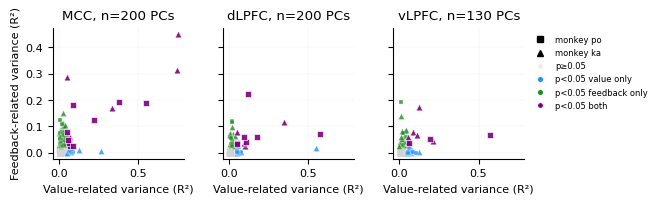

In [19]:
def plot_explained_variance(res_all, n_comps=10000, paperformat=False):
    
    if paperformat:
        plt.rcParams.update({'font.size': 8})
        lw = 1
        s_s, s_t = 13*1.2, 20*1.2
        h, w = 2.5*.85 * .8, 6*.85 * .8 + 2
    else:   
        plt.rcParams.update({'font.size': 18})
        lw = 3
        s = 40
        h, w = 4, 13

    # no gap between subplots
    fig, axs = plt.subplots(1, 3, figsize=(w, h), sharex=True, sharey=True, gridspec_kw={'wspace': 0.3})

    # rectangle and triangle markers for monkeys
    markers = {'po': 's', 'ka': '^'}
    sizes = {'po': s_s, 'ka': s_t}

    for ax_i, area in enumerate(['MCC', 'dLPFC', 'vLPFC']):

        n_comps_all = 0
        for monkey in ['ka', 'po']:
            res = res_all[monkey]
            n_components = np.min((n_comps, len(res[area]['r2s_value'])))
            n_comps_all += n_components

            r2s_value = res[area]['r2s_value'][:n_components]
            pvals_value = res[area]['pvals_value'][:n_components]
            r2s_feedback = res[area]['r2s_feedback'][:n_components]
            pvals_feedback = res[area]['pvals_feedback'][:n_components]

            # Get current axis
            ax = axs[ax_i]
            
            # Separate points by significance pattern
            both_sig = (pvals_value < 0.05) & (pvals_feedback < 0.05)
            value_only = (pvals_value < 0.05) & (pvals_feedback >= 0.05)
            feedback_only = (pvals_value >= 0.05) & (pvals_feedback < 0.05)
            neither_sig = (pvals_value >= 0.05) & (pvals_feedback >= 0.05)
            
            # Plot points with clear visual hierarchy (no numbers!)
            if np.any(neither_sig):
                ax.scatter(r2s_value[neither_sig], r2s_feedback[neither_sig], 
                        c='lightgrey', alpha=0.4, s=sizes[monkey]*0.6, zorder=1, marker=markers[monkey])

            if np.any(value_only):
                ax.scatter(r2s_value[value_only], r2s_feedback[value_only], 
                        c='dodgerblue', alpha=0.8, s=sizes[monkey]*0.8, zorder=2, 
                        edgecolors='white', linewidths=lw*0.3, marker=markers[monkey])

            if np.any(feedback_only):
                ax.scatter(r2s_value[feedback_only], r2s_feedback[feedback_only], 
                        c='forestgreen', alpha=0.8, s=sizes[monkey]*0.8, zorder=2, 
                        edgecolors='white', linewidths=lw*0.3, marker=markers[monkey])

            if np.any(both_sig):
                ax.scatter(r2s_value[both_sig], r2s_feedback[both_sig], 
                        c='purple', alpha=0.9, s=sizes[monkey], zorder=3, 
                        edgecolors='white', linewidths=lw*0.5, marker=markers[monkey])

            # Add diagonal reference line
            #max_val_value = np.max(r2s_value) * 1.1
            #max_val_feedback = np.max(r2s_feedback) * 1.1
            #max_value = max(max_val_value, max_val_feedback)

            '''ax.plot([0, 1], [0, 1], '--', color='darkgrey', 
                    alpha=0.6, linewidth=lw*0.8, zorder=0, label='Unity line')'''
            
        # Clean styling
        ax.set_xlabel('Value-related variance (R²)')
        ax.set_title(f'{area}, n={n_comps_all} PCs')
        
        # Set clean axis limits
        '''ax.set_xlim(-0.005, max_val_value)
        ax.set_ylim(-0.005, max_val_feedback)'''

        # Minimal grid
        ax.grid(True, alpha=0.2, linewidth=lw*0.3)
        
        # Clean spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        #ax.spines['left'].set_linewidth(lw*0.5)
        #ax.spines['bottom'].set_linewidth(lw*0.5)
        #ax.tick_params(width=lw*0.5, length=lw*2)

    # Legend only on first subplot
    legend_elements = [
       plt.Line2D([0], [0], marker='s', color='w', label='monkey po', markerfacecolor='k', markersize=4, markeredgecolor='k', markeredgewidth=1),
       plt.Line2D([0], [0], marker='^', color='w', label='monkey ka', markerfacecolor='k', markersize=4, markeredgecolor='k', markeredgewidth=1),
       plt.Line2D([0], [0], marker='o', color='w', label='p≥0.05', markerfacecolor='lightgrey', markersize=4, alpha=0.4),
       plt.Line2D([0], [0], marker='o', color='w', label='p<0.05 value only', markerfacecolor='dodgerblue', markersize=4, markeredgecolor='white', markeredgewidth=lw*0.3),
       plt.Line2D([0], [0], marker='o', color='w', label='p<0.05 feedback only', markerfacecolor='forestgreen', markersize=4, markeredgecolor='white', markeredgewidth=lw*0.3),
       plt.Line2D([0], [0], marker='o', color='w', label='p<0.05 both', markerfacecolor='purple', markersize=4, markeredgecolor='white', markeredgewidth=lw*0.5),
    ]
    
    axs[0].set_ylabel('Feedback-related variance (R²)')

    # legend outside of plot
    axs[2].legend(handles=legend_elements, loc='upper right', 
                  frameon=False, fancybox=False, shadow=False, 
                  fontsize=plt.rcParams['font.size']*0.75, bbox_to_anchor=(2, 1))
    
    plt.tight_layout()
    return fig, axs

fig, axs = plot_explained_variance(res_all, n_comps=2000, paperformat=True)


---
# Multi-dimensional PCA plots

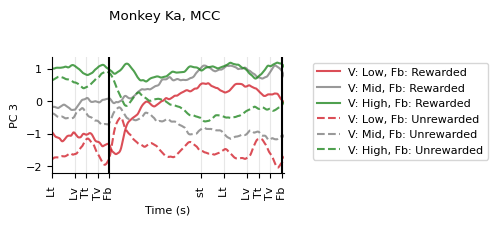

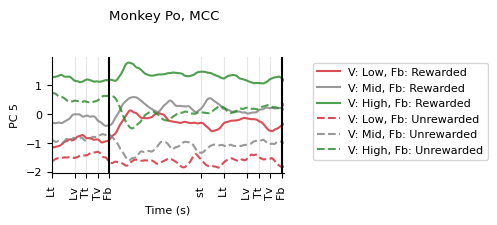

In [24]:
# plot setting: normal, not 3d or interactive

pca_comps = [('ka', 3), ('po', 5)]  # 5 for PO, 3 for KA

# Plot PCA trajectory for each area
for monkey, pca_comp_temp in pca_comps:
    fig, ax = plot_pca_trajectory(pca_dataset_all[monkey]['MCC'], monkey, pca_comp_temp, paper_format=True)
    fig.suptitle(f'Monkey {monkey.capitalize()}, MCC', y=1.2)

    # remove legend
    handles, labels = ax.get_legend_handles_labels()
    #ax.legend_.remove()
